<a href="https://colab.research.google.com/github/7yl4r/HabEvent/blob/main/HabEventS2SeagrassStAndrews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
interestRegionExtractionURL = "https://raw.githubusercontent.com/7yl4r/HabEvent/refs/heads/main/aoi-extractions/St_Andrews_seagrass_restoration.csv"
referenceRegionExtractionURL = "https://raw.githubusercontent.com/7yl4r/HabEvent/refs/heads/main/aoi-extractions/St_Andrews_seagrass_restoration_reference_region.csv"

In [4]:
# csv fetching function
import pandas as pd
import urllib.request
from io import StringIO

def extract_and_clean_region_data(url):
    """
    Fetches CSV data from a URL, parses dates, and cleans empty band rows.
    """
    # Fetch the CSV
    with urllib.request.urlopen(url) as response:
        csv_text = response.read().decode("utf-8")

    # Parse CSV
    df = pd.read_csv(StringIO(csv_text))

    # Parse dates and set as index
    if "system:time_start" in df.columns:
        df["system:time_start"] = pd.to_datetime(df["system:time_start"])
        df = df.set_index("system:time_start").sort_index()

    return df

# Example usage:
# df_final = extract_and_clean_region_data(interestRegionExtractionURL)

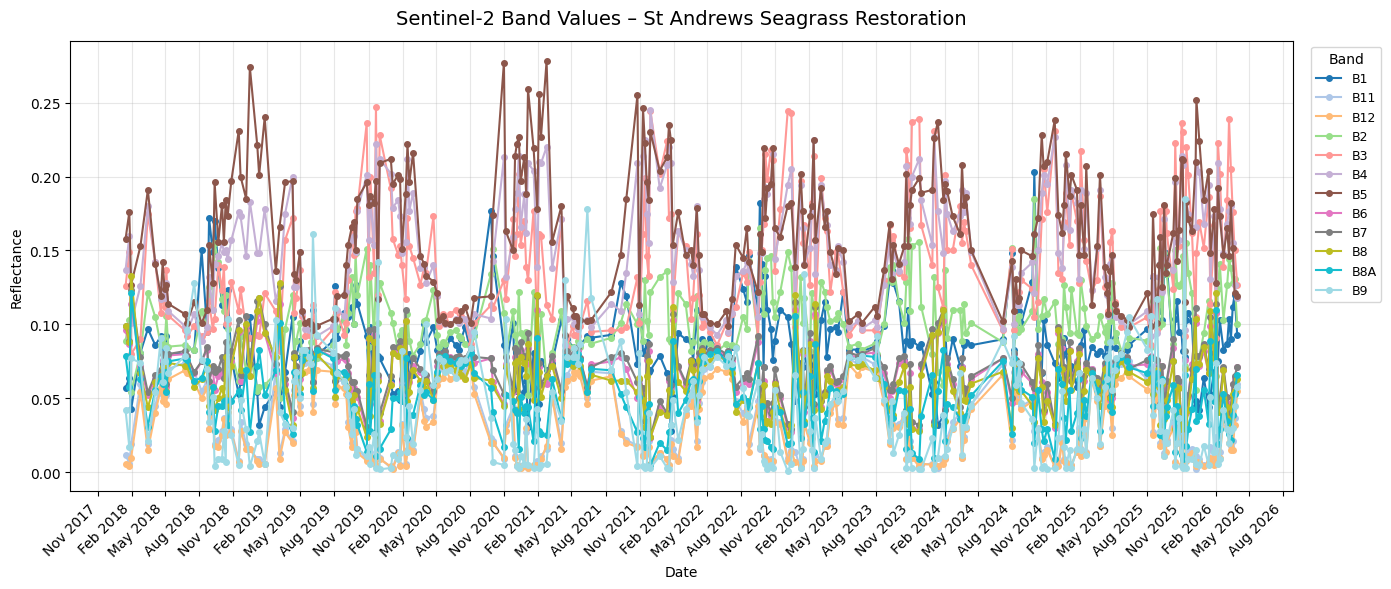

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from io import StringIO
import urllib.request

# Fetch the CSVs
df_interestRegion = extract_and_clean_region_data(interestRegionExtractionURL)
df_referenceRegion = extract_and_clean_region_data(referenceRegionExtractionURL)


df_interestRegion

# ==============================================================================
# ── Plot ──────────────────────────────────────────────────────────────────────
# ==============================================================================
fig, ax = plt.subplots(figsize=(14, 6))

# Band columns
band_cols = [c for c in df.columns if c.startswith("B")]

cmap = plt.get_cmap("tab20", len(band_cols))
for i, band in enumerate(band_cols):
    series = df_interestRegion[band].dropna()
    ax.plot(series.index, series.values, marker="o", markersize=4,
            linewidth=1.5, label=band, color=cmap(i))

ax.set_title("Sentinel-2 Band Values – St Andrews Seagrass Restoration", fontsize=14, pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("Reflectance")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha="right")
ax.legend(title="Band", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
